## Decoding music preference from EEG

*Research question:* Can we reliably decode binary music preference (like vs. dislike)
from EEG signals recorded during music listening?

#### Table of contents

1. [Introduction and background](#1-introduction-and-background)
2. [Dataset](#2-dataset)
3. [Data exploration](#3-data-exploration)
4. [Feature engineering](#4-feature-engineering)
5. [Classification](#5-classification)
6. [Interpretability and advanced analysis](#6-interpretability-and-advanced-analysis)
7. [Discussion and conclusion](#7-discussion-and-conclusion)
8. [References](#8-references)

### 1. Introduction and background

Music preference is a subjective experience that manifests in measurable neural activity. This project investigates whether we can decode binary music preference from EEG signals recorded during music listening, using the DEAP dataset.

The *approach-withdrawal model* (Davidson, 1992) predicts that preferred stimuli are associated with greater left frontal cortical activity, captured by frontal alpha asymmetry (FAA). We hypothesize that FAA features will rank among the most predictive for preference classification.

The pipeline covers data exploration, feature engineering (164-dim baseline: differential entropy + frontal alpha asymmetry), classification with SVM, XGBoost, and Random Forest, and interpretability analyses including SHAP, time-resolved decoding, and familiarity disentanglement.


In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*align.*")
warnings.filterwarnings("ignore", message=".*feature names.*")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from IPython.display import display, Markdown
from scipy.signal import welch

from src.data import (
    load_subject, get_trial_data, binarize_liking,
    binarize_with_margin,
    AVAILABLE_SUBJECTS, EEG_CHANNELS, SAMPLING_RATE,
    N_TRIALS, BASELINE_SAMPLES, TRIAL_SAMPLES,
)
from src.features import (
    FREQ_BANDS, FRONTAL_PAIRS,
    extract_differential_entropy, extract_frontal_alpha_asymmetry,
    extract_features_for_subject,
    get_feature_names,
    compute_band_power_ratios, compute_petrosian_fd,
    compute_spectral_entropy,
)
from src.classify import (
    within_subject_cv,
    majority_vote_cv,
)
from src.interpret import compute_shap_values, get_top_features
from src.interpret import time_resolved_classification, find_decodable_time
from src.interpret import run_familiarity_analysis
from src.visualize import setup_style

setup_style()
sns.set_palette("colorblind")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (12, 5)})


### 2. Dataset

We use the DEAP dataset (Koelstra et al., 2012), a widely used benchmark for affective computing.

| Property | Value |
|---|---|
| Participants | 32 healthy adults (16 male, 16 female, age 19-37) |
| Stimuli | 40 one-minute music video excerpts |
| EEG channels | 32 (BioSemi active electrode system) |
| Sampling rate | 128 Hz (downsampled from 512 Hz) |
| Trial structure | 3s baseline + 60s stimulus = 63s per trial |
| Self-report | Valence, Arousal, Dominance, Liking (1-9 continuous scale) |
| Preprocessing | Downsampled, EOG artifact removal, bandpass 4-45 Hz |

### 3. Data exploration

#### 3.1 Loading a single subject

In [2]:
data, labels = load_subject(1, eeg_only=True)
trial_data = get_trial_data(data, include_baseline=False)
trial_0 = trial_data[0]
fz_index = EEG_CHANNELS.index("Fz")
fz_signal = trial_0[fz_index]

display(Markdown(f"""Subject s01 data structure:

| Property | Value |
|---|---|
| Data shape | `{data.shape}` *(trials, channels, samples)* |
| Labels shape | `{labels.shape}` *(trials, rating dimensions)* |
| EEG channels | {len(EEG_CHANNELS)} |
| Sampling rate | {SAMPLING_RATE} Hz |
| Duration per trial | {data.shape[2] / SAMPLING_RATE:.1f}s ({BASELINE_SAMPLES / SAMPLING_RATE:.0f}s baseline + {TRIAL_SAMPLES / SAMPLING_RATE:.0f}s stimulus) |
| Total subjects | {len(AVAILABLE_SUBJECTS)} |
| Total trials | {len(AVAILABLE_SUBJECTS) * N_TRIALS} |
"""))


Subject s01 data structure:

| Property | Value |
|---|---|
| Data shape | `(40, 32, 8064)` *(trials, channels, samples)* |
| Labels shape | `(40, 4)` *(trials, rating dimensions)* |
| EEG channels | 32 |
| Sampling rate | 128 Hz |
| Duration per trial | 63.0s (3s baseline + 60s stimulus) |
| Total subjects | 32 |
| Total trials | 1280 |


#### 3.2 Self-report rating distributions

Each trial is rated on four dimensions (1-9 scale). We focus on *liking* for binary classification.

In [3]:
all_labels = []
for subject_id in AVAILABLE_SUBJECTS:
    subject_data, subject_labels = load_subject(subject_id, eeg_only=True)
    all_labels.append(subject_labels)
all_labels = np.vstack(all_labels)

lines = [
    f"Rating statistics across all {len(all_labels)} trials (32 subjects x 40 trials):",
    "",
    "| Dimension | Mean | Std | Min | Max | Median |",
    "|---|---|---|---|---|---|",
]
for dimension, name in enumerate(["Valence", "Arousal", "Dominance", "Liking"]):
    values = all_labels[:, dimension]
    lines.append(f"| {name} | {values.mean():.2f} | {values.std():.2f} | {values.min():.1f} | {values.max():.1f} | {np.median(values):.2f} |")
display(Markdown("\n".join(lines)))

Rating statistics across all 1280 trials (32 subjects x 40 trials):

| Dimension | Mean | Std | Min | Max | Median |
|---|---|---|---|---|---|
| Valence | 5.25 | 2.13 | 1.0 | 9.0 | 5.04 |
| Arousal | 5.16 | 2.02 | 1.0 | 9.0 | 5.23 |
| Dominance | 5.38 | 2.10 | 1.0 | 9.0 | 5.24 |
| Liking | 5.52 | 2.28 | 1.0 | 9.0 | 6.05 |

/var/folders/_f/171dt4kn19sf0yq1gqhrb_lh0000gn/T/ipykernel_27400/3212862406.py:16: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


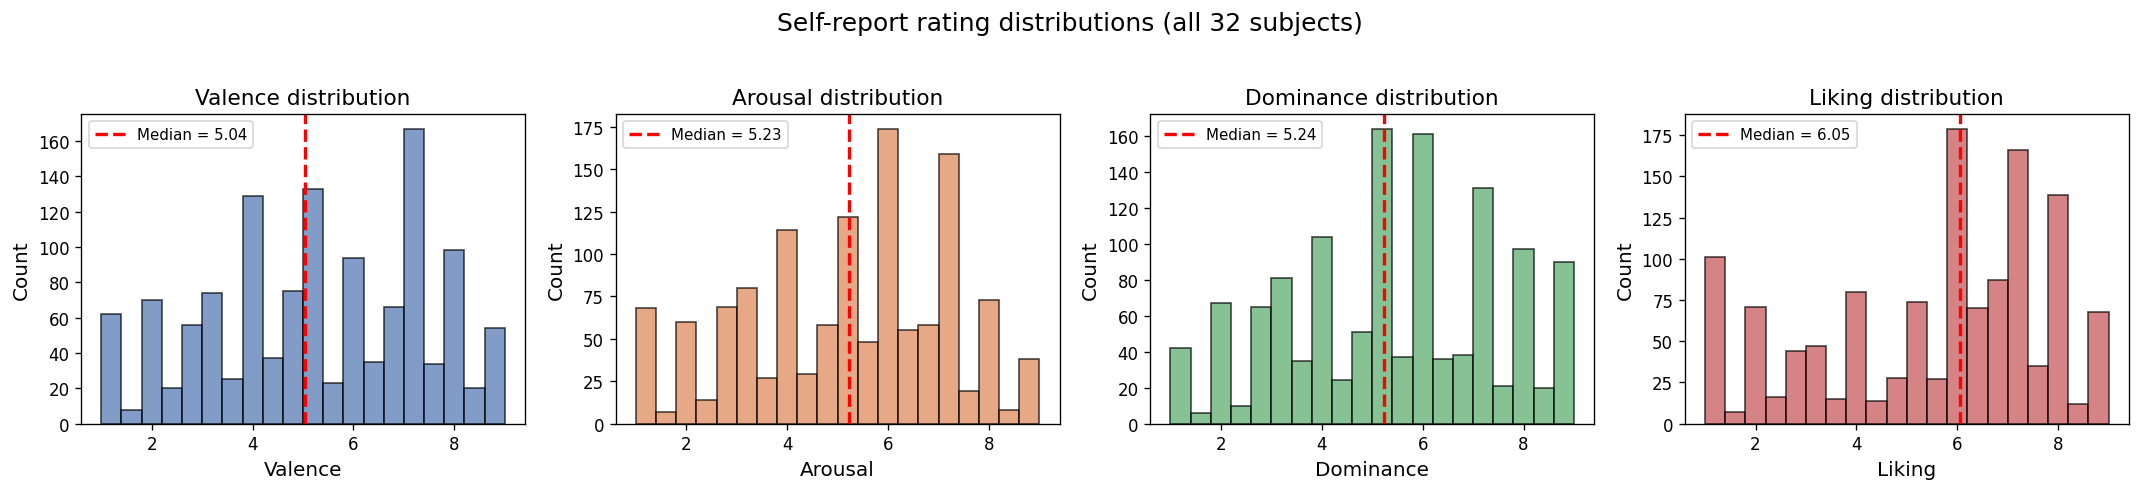

In [4]:
figure, axes = plt.subplots(1, 4, figsize=(18, 4))
dimension_names = ["Valence", "Arousal", "Dominance", "Liking"]
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

for axis, dimension, name, color in zip(axes, range(4), dimension_names, colors):
    axis.hist(all_labels[:, dimension], bins=20, edgecolor="black", alpha=0.7, color=color)
    median_value = np.median(all_labels[:, dimension])
    axis.axvline(median_value, color="red", linestyle="--", linewidth=2,
               label=f"Median = {median_value:.2f}")
    axis.set_xlabel(name, fontsize=12)
    axis.set_ylabel("Count")
    axis.set_title(f"{name} distribution", fontsize=13)
    axis.legend(fontsize=9)

plt.suptitle("Self-report rating distributions (all 32 subjects)", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

#### 3.3 Binarization: like vs. dislike

We convert continuous liking ratings into a binary task using a per-subject median split, the standard approach in the DEAP literature.

In [5]:
class_counts = {"like": 0, "dislike": 0}
subject_balance = []

for subject_id in AVAILABLE_SUBJECTS:
    subject_data, subject_labels = load_subject(subject_id, eeg_only=True)
    binary_labels = binarize_liking(subject_labels)
    num_like = int(binary_labels.sum())
    num_dislike = int((1 - binary_labels).sum())
    class_counts["like"] += num_like
    class_counts["dislike"] += num_dislike
    subject_balance.append(num_like / len(binary_labels))

total = class_counts["like"] + class_counts["dislike"]
display(Markdown(f"""Class distribution after median-split binarization:

| Class | Count | Fraction |
|---|---|---|
| Like (1) | {class_counts['like']} | {class_counts['like'] / total:.1%} |
| Dislike (0) | {class_counts['dislike']} | {class_counts['dislike'] / total:.1%} |

"""))

Class distribution after median-split binarization:

| Class | Count | Fraction |
|---|---|---|
| Like (1) | 638 | 49.8% |
| Dislike (0) | 642 | 50.2% |



#### 3.4 Electrode layout

The DEAP dataset uses the BioSemi 32-channel cap following the 10-20 system. Frontal electrodes are particularly relevant for the FAA hypothesis.

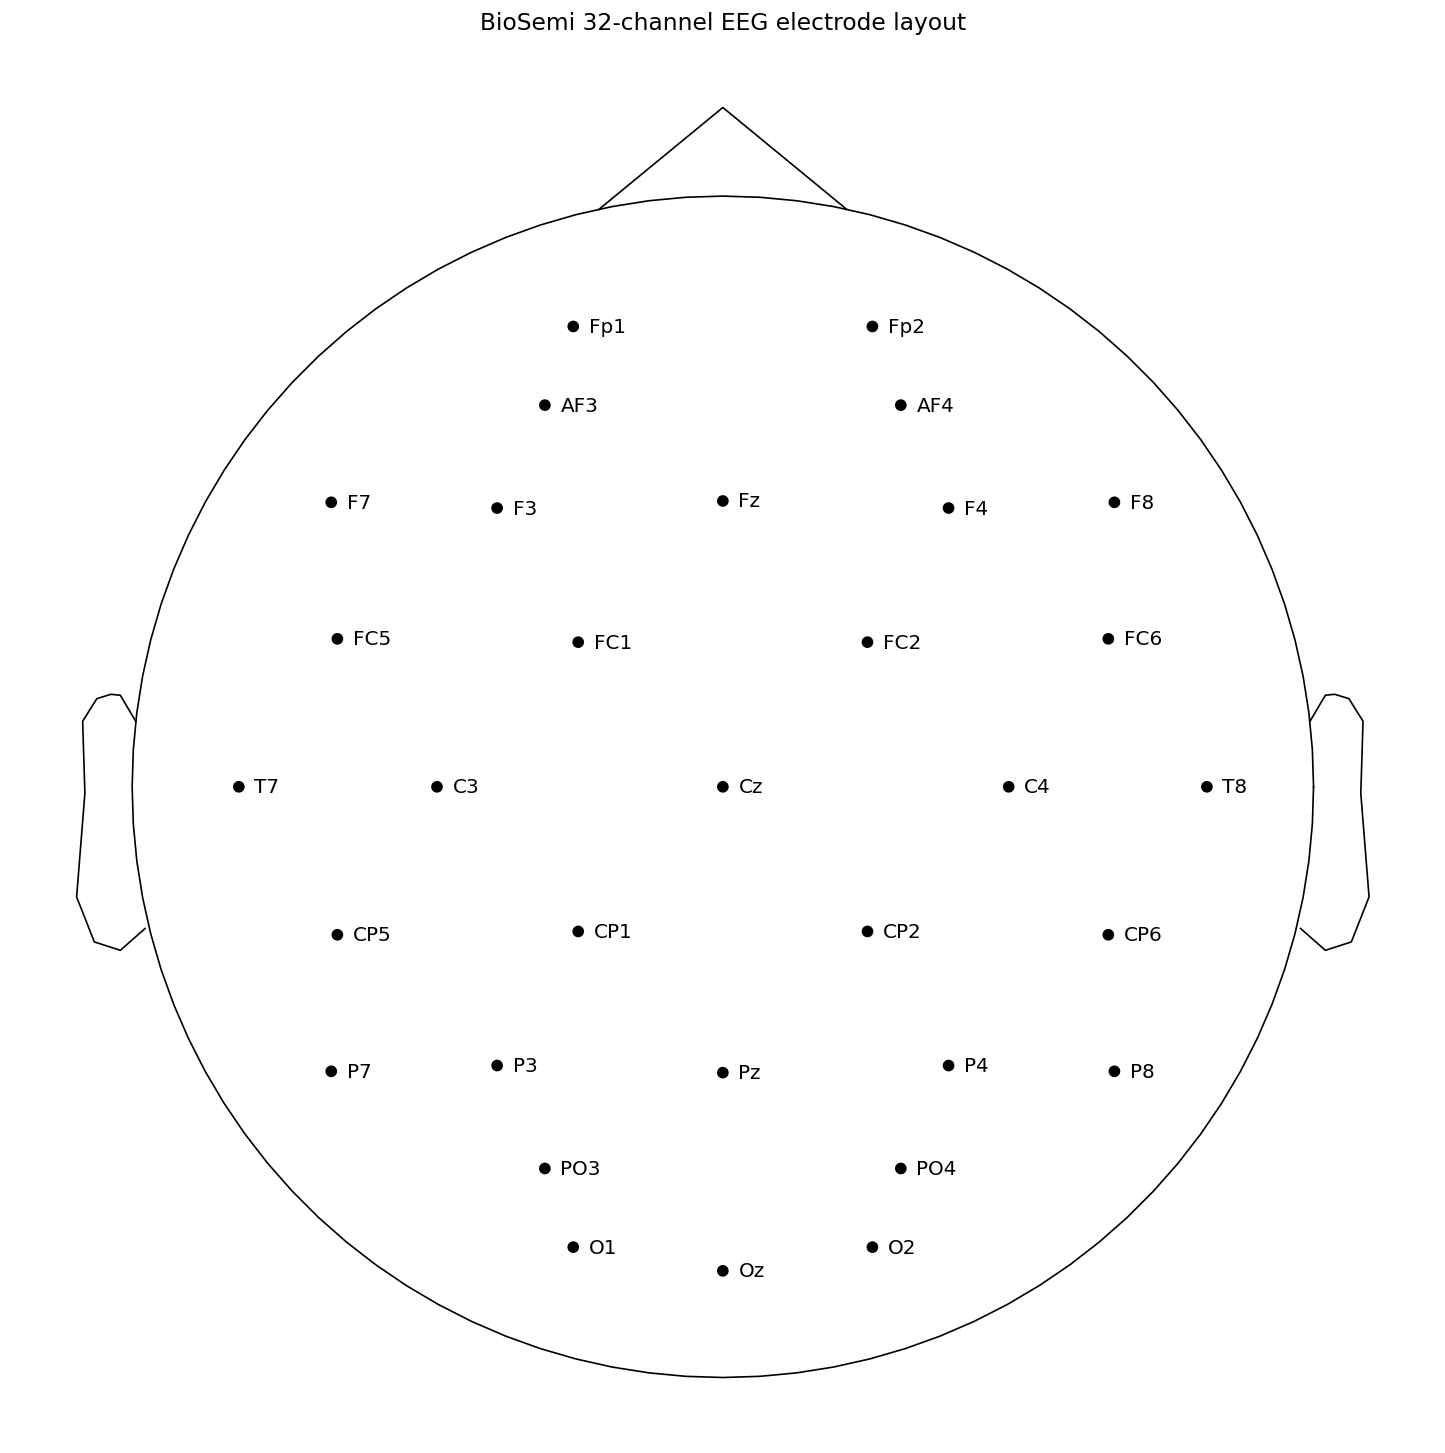

In [6]:
import mne

info = mne.create_info(ch_names=EEG_CHANNELS, sfreq=SAMPLING_RATE, ch_types="eeg")
montage = mne.channels.make_standard_montage("biosemi32")
info.set_montage(montage)

figure = montage.plot(kind="topomap", show_names=True, show=False)
figure.suptitle("BioSemi 32-channel EEG electrode layout", fontsize=14)
plt.show()

#### 3.5 Power spectral density

EEG information is distributed across frequency bands:

| Band | Frequency | Associated states |
|---|---|---|
| Delta | 1-4 Hz | Deep sleep, unconscious processing |
| Theta | 4-8 Hz | Memory encoding, emotional processing |
| Alpha | 8-13 Hz | Relaxation, inhibition, idling |
| Beta | 13-30 Hz | Active thinking, attention, engagement |
| Gamma | 30-45 Hz | Higher-order processing, binding |

/var/folders/_f/171dt4kn19sf0yq1gqhrb_lh0000gn/T/ipykernel_27400/53369345.py:28: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


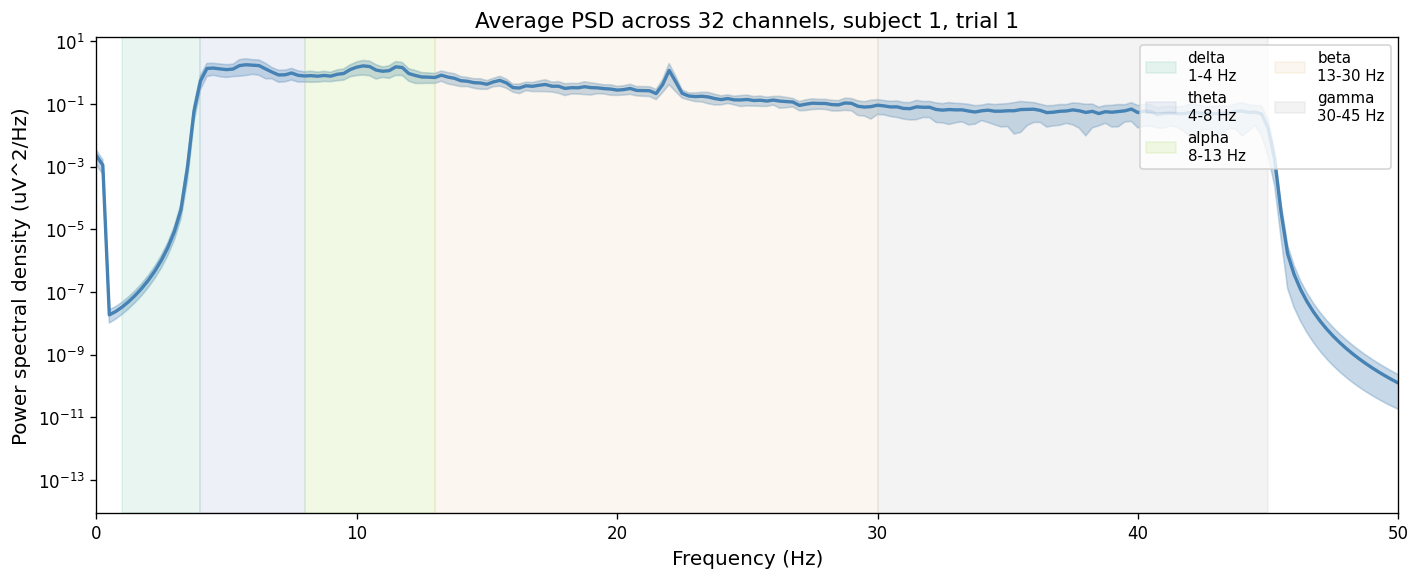

In [7]:
figure, axis = plt.subplots(figsize=(12, 5))

frequency_list, power_spectrum_list = [], []
for channel_index in range(trial_0.shape[0]):
    frequencies, power_spectrum = welch(trial_0[channel_index], fs=SAMPLING_RATE, nperseg=512)
    frequency_list.append(frequencies)
    power_spectrum_list.append(power_spectrum)

freqs = frequency_list[0]
mean_power = np.mean(power_spectrum_list, axis=0)
std_power = np.std(power_spectrum_list, axis=0)

axis.semilogy(frequencies, mean_power, color="steelblue", linewidth=2)
axis.fill_between(frequencies, np.maximum(mean_power - std_power, 1e-30), mean_power + std_power, alpha=0.3, color="steelblue")

band_colors = {"delta\n1-4 Hz": (1, 4), "theta\n4-8 Hz": (4, 8),
               "alpha\n8-13 Hz": (8, 13), "beta\n13-30 Hz": (13, 30),
               "gamma\n30-45 Hz": (30, 45)}
colormap_values = plt.cm.Set2(np.linspace(0, 1, 5))
for (label, (low_freq, high_freq)), color in zip(band_colors.items(), colormap_values):
    axis.axvspan(low_freq, high_freq, alpha=0.15, color=color, label=label)

axis.set_xlabel("Frequency (Hz)", fontsize=12)
axis.set_ylabel("Power spectral density (uV^2/Hz)", fontsize=12)
axis.set_title("Average PSD across 32 channels, subject 1, trial 1", fontsize=13)
axis.set_xlim(0, 50)
axis.legend(loc="upper right", fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

### 4. Feature engineering

#### 4.1 Baseline features: differential entropy (DE)

Differential entropy measures information content per frequency band:

$$DE = \frac{1}{2} \ln(2\pi e \sigma^2)$$

where $\sigma^2$ is band power via Welch's method. DE is the most effective single feature type for EEG emotion recognition (Shi et al., 2013). We compute DE for 32 channels across 5 bands, yielding 160 features.

Differential entropy feature vector: `(160,)` = 32 channels x 5 bands

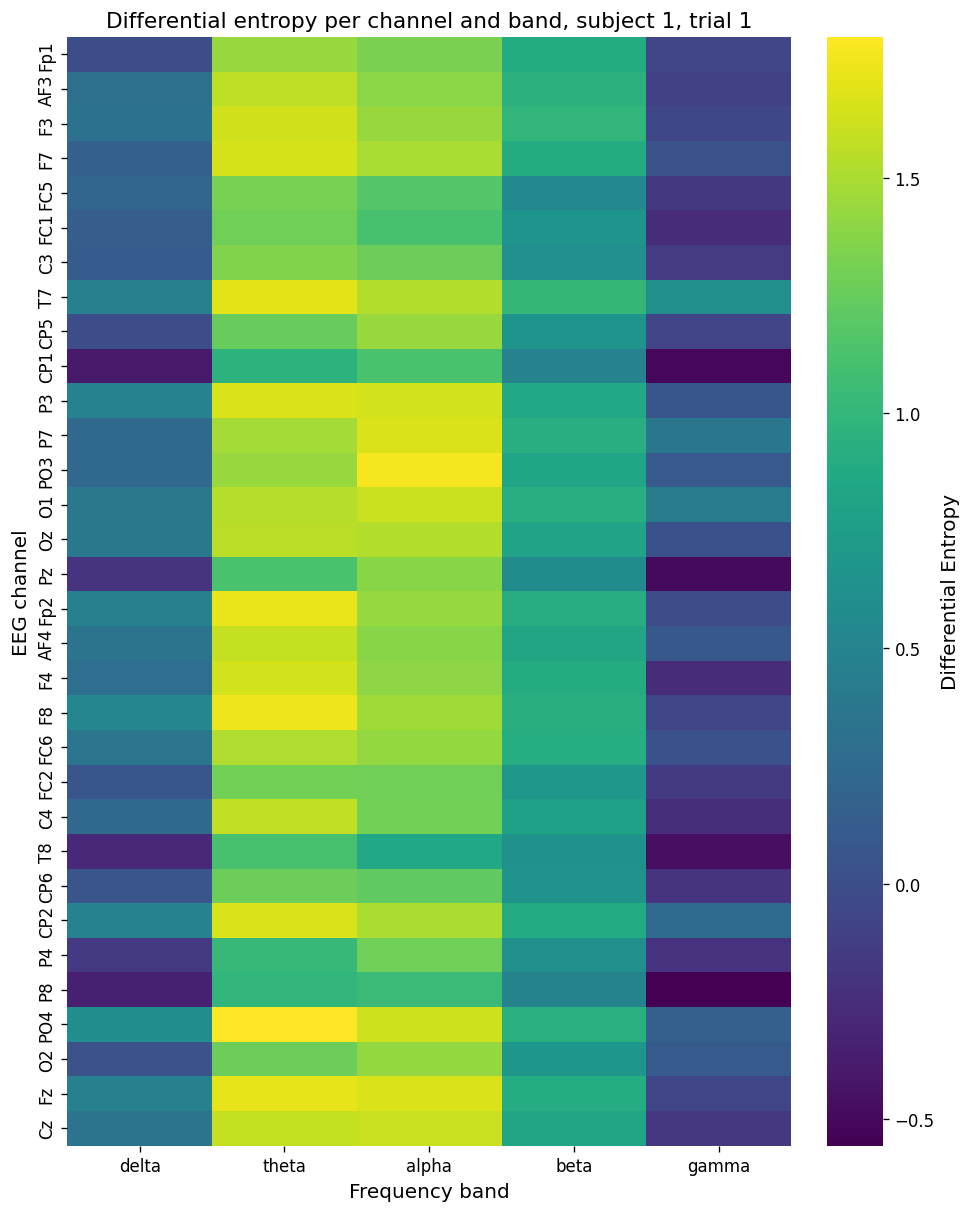

In [8]:
de_features = extract_differential_entropy(trial_0, SAMPLING_RATE)
de_matrix = de_features.reshape(len(EEG_CHANNELS), len(FREQ_BANDS))

display(Markdown(f"Differential entropy feature vector: `{de_features.shape}` = {len(EEG_CHANNELS)} channels x {len(FREQ_BANDS)} bands"))

figure, axis = plt.subplots(figsize=(8, 10), layout="constrained")
sns.heatmap(de_matrix, ax=axis, cmap="viridis",
            xticklabels=list(FREQ_BANDS.keys()),
            yticklabels=EEG_CHANNELS,
            cbar_kws={"label": "Differential Entropy"})
axis.set_title("Differential entropy per channel and band, subject 1, trial 1", fontsize=13)
axis.set_xlabel("Frequency band", fontsize=12)
axis.set_ylabel("EEG channel", fontsize=12)
plt.show()

#### 4.2 Baseline features: frontal alpha asymmetry (FAA)

FAA captures hemispheric alpha-band power differences between homologous frontal pairs:

$$FAA = \ln(\alpha_{right}) - \ln(\alpha_{left})$$

Positive FAA indicates greater left frontal activation, associated with approach motivation. We compute FAA for 4 pairs: Fp2-Fp1, AF4-AF3, F4-F3, F8-F7.

Frontal alpha asymmetry, subject 1, trial 1:

| Electrode pair (R - L) | FAA value |
|---|---|
| Fp2 - Fp1 | +0.1973 |
| AF4 - AF3 | -0.0115 |
| F4 - F3 | -0.0793 |
| F8 - F7 | -0.0516 |

/var/folders/_f/171dt4kn19sf0yq1gqhrb_lh0000gn/T/ipykernel_27400/641536004.py:24: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


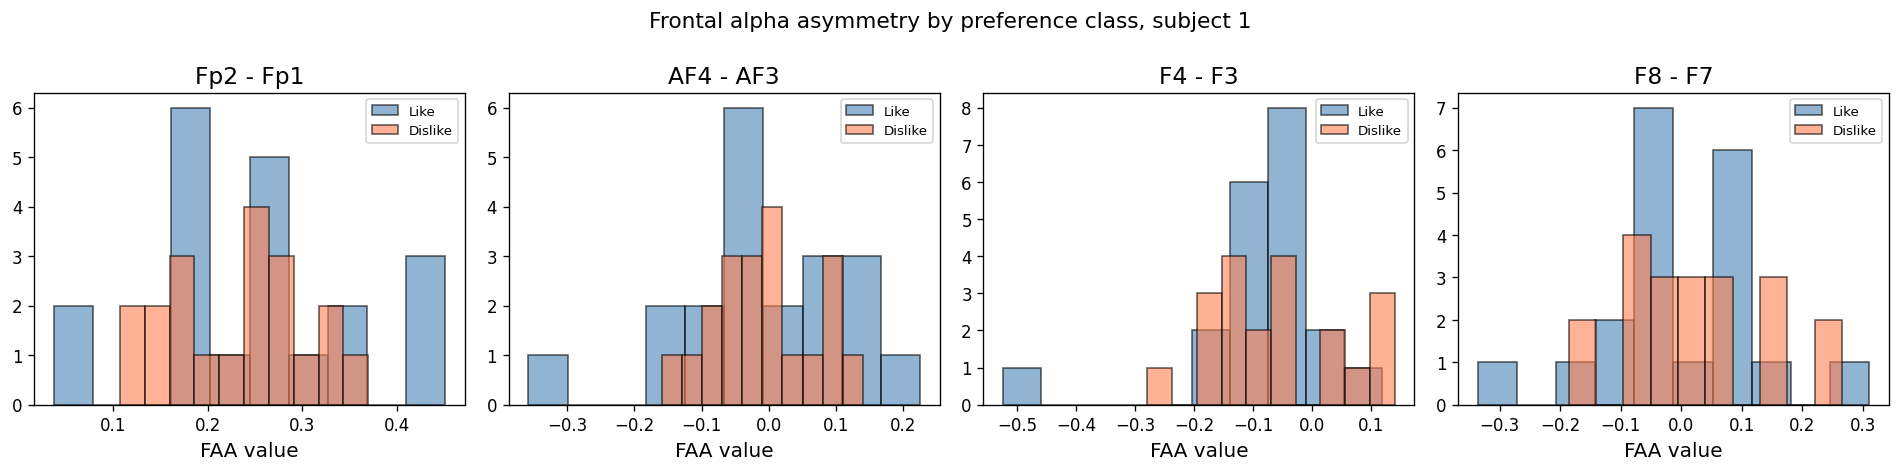

In [9]:
faa_features = extract_frontal_alpha_asymmetry(trial_0, SAMPLING_RATE)

lines = ["Frontal alpha asymmetry, subject 1, trial 1:", "", "| Electrode pair (R - L) | FAA value |", "|---|---|"]
for (right, left), value in zip(FRONTAL_PAIRS, faa_features):
    lines.append(f"| {right} - {left} | {value:+.4f} |")
display(Markdown("\n".join(lines)))

y_s1 = binarize_liking(labels)
faa_all_trials = np.zeros((len(trial_data), len(FRONTAL_PAIRS)))
for trial_index in range(len(trial_data)):
    faa_all_trials[trial_index] = extract_frontal_alpha_asymmetry(trial_data[trial_index], SAMPLING_RATE)

figure, axes = plt.subplots(1, len(FRONTAL_PAIRS), figsize=(16, 4))
for axis, pair_index, (right, left) in zip(axes, range(len(FRONTAL_PAIRS)), FRONTAL_PAIRS):
    for class_value, label, color in [(1, "Like", "steelblue"), (0, "Dislike", "coral")]:
        class_mask = y_s1 == class_value
        axis.hist(faa_all_trials[class_mask, pair_index], bins=10, alpha=0.6,
                label=label, color=color, edgecolor="black")
    axis.set_xlabel("FAA value")
    axis.set_title(f"{right} - {left}")
    axis.legend(fontsize=8)

plt.suptitle("Frontal alpha asymmetry by preference class, subject 1", fontsize=13)
plt.tight_layout()
plt.show()

#### 4.3 Complete baseline feature vector

The baseline feature set combines DE and FAA as summarized below.

| Feature Type | Dimensions |
|---|---|
| Differential Entropy | 32 channels x 5 bands = 160 |
| Frontal Alpha Asymmetry | 4 electrode pairs = 4 |
| Total | 164 |


In [10]:
X_baseline = extract_features_for_subject(trial_data, SAMPLING_RATE)

display(Markdown(f"""Baseline feature matrix for subject 1: `{X_baseline.shape}` (trials x features)

| Statistic | Value |
|---|---|
| Mean | {X_baseline.mean():.4f} |
| Std | {X_baseline.std():.4f} |
| Range | [{X_baseline.min():.4f}, {X_baseline.max():.4f}] |
"""))

Baseline feature matrix for subject 1: `(40, 164)` (trials x features)

| Statistic | Value |
|---|---|
| Mean | 0.7807 |
| Std | 0.6723 |
| Range | [-0.5745, 2.4034] |


### 5. Classification

We evaluate three strategies using 5-fold stratified cross-validation per subject: (1) baseline 164-dim features with median binarization, (2) baseline features with margin binarization (removing ambiguous trials), and (3) majority vote ensemble combining XGBoost, RandomForest, and LightGBM.


#### 5.1 Margin-based binarization

Margin binarization removes ambiguous trials near the median, trading dataset size for label quality.

In [11]:
demo_subjects = [1, 2, 3]

lines = [
    "Effect of margin binarization (margin = 0.5):",
    "",
    "| Subject | Median split (n) | Margin split (n) | Trials removed |",
    "|---|---|---|---|",
]
for subject_id in demo_subjects:
    subject_data, subject_labels = load_subject(subject_id, eeg_only=True)
    labels_median = binarize_liking(subject_labels)
    labels_margin, margin_mask = binarize_with_margin(subject_labels, margin=0.5)
    removed = len(labels_median) - len(labels_margin)
    lines.append(f"| s{subject_id:02d} | {len(labels_median)} | {len(labels_margin)} | {removed} ({removed/len(labels_median):.0%}) |")
display(Markdown("\n".join(lines)))

Effect of margin binarization (margin = 0.5):

| Subject | Median split (n) | Margin split (n) | Trials removed |
|---|---|---|---|
| s01 | 40 | 27 | 13 (32%) |
| s02 | 40 | 31 | 9 (22%) |
| s03 | 40 | 27 | 13 (32%) |

#### 5.2 Full 32-subject comparison

We run all three strategies on all 32 subjects.


In [12]:
all_baseline_accs = []
all_baseline_margin_accs = []
all_vote_accs = []
subject_results = {}

time_start = time.time()

for subject_id in AVAILABLE_SUBJECTS:
    print(f"s{subject_id:02d}...", end=" ", flush=True)

    subject_data, subject_labels = load_subject(subject_id, eeg_only=True)
    subject_trial_data = get_trial_data(subject_data, include_baseline=False)
    labels_median = binarize_liking(subject_labels)

    baseline_features = extract_features_for_subject(subject_trial_data, SAMPLING_RATE)
    baseline_results = within_subject_cv(baseline_features, labels_median)
    best_baseline = max(baseline_results.values(), key=lambda result: result["accuracy"])["accuracy"]
    all_baseline_accs.append(best_baseline)

    labels_margin, margin_mask = binarize_with_margin(subject_labels, margin=0.5)

    if len(labels_margin) >= 10 and len(np.unique(labels_margin)) >= 2:
        baseline_margin_features = baseline_features[margin_mask]
        baseline_margin_results = within_subject_cv(baseline_margin_features, labels_margin)
        best_baseline_margin = max(baseline_margin_results.values(), key=lambda result: result["accuracy"])["accuracy"]
    else:
        best_baseline_margin = 0.5
    all_baseline_margin_accs.append(best_baseline_margin)

    vote_results = majority_vote_cv(baseline_features, labels_median)
    all_vote_accs.append(vote_results["accuracy"])

    subject_results[subject_id] = {
        "baseline": best_baseline,
        "baseline_margin": best_baseline_margin,
        "vote": vote_results["accuracy"],
    }

    print(f"base={best_baseline:.1%} base+margin={best_baseline_margin:.1%} vote={vote_results['accuracy']:.1%}")

elapsed = time.time() - time_start
display(Markdown(f"Total classification time: {elapsed / 60:.1f} minutes"))


s01... base=55.0% base+margin=55.3% vote=47.5%
s02... base=67.5% base+margin=64.3% vote=55.0%
s03... base=75.0% base+margin=77.3% vote=72.5%
s04... base=67.5% base+margin=68.1% vote=57.5%
s05... base=57.5% base+margin=54.3% vote=60.0%
s06... base=55.0% base+margin=53.3% vote=47.5%
s07... base=67.5% base+margin=70.0% vote=67.5%
s08... base=47.5% base+margin=35.3% vote=42.5%
s09... base=50.0% base+margin=72.0% vote=45.0%
s10... base=75.0% base+margin=82.7% vote=67.5%
s11... base=40.0% base+margin=44.6% vote=45.0%
s12... base=65.0% base+margin=57.3% vote=65.0%
s13... base=80.0% base+margin=78.6% vote=77.5%
s14... base=70.0% base+margin=58.6% vote=67.5%
s15... base=72.5% base+margin=69.5% vote=47.5%
s16... base=70.0% base+margin=77.1% vote=52.5%
s17... base=55.0% base+margin=71.0% vote=52.5%
s18... base=57.5% base+margin=66.7% vote=47.5%
s19... base=77.5% base+margin=77.1% vote=72.5%
s20... base=80.0% base+margin=83.3% vote=75.0%
s21... base=60.0% base+margin=59.3% vote=45.0%
s22... base=4

Total classification time: 2.8 minutes

#### 5.3 Results summary

In [13]:
strategies = {
    "Baseline (164-dim, median)": all_baseline_accs,
    "Baseline + Margin binariz.": all_baseline_margin_accs,
    "Majority Vote Ensemble": all_vote_accs,
}

lines = [
    "Classification results across all 32 subjects",
    "",
    "| Strategy | Mean accuracy | Std | Min | Max |",
    "|---|---|---|---|---|",
]
for name, accuracies in strategies.items():
    lines.append(f"| {name} | {np.mean(accuracies):.1%} | {np.std(accuracies):.1%} | {np.min(accuracies):.1%} | {np.max(accuracies):.1%} |")
display(Markdown("\n".join(lines)))


Classification results across all 32 subjects

| Strategy | Mean accuracy | Std | Min | Max |
|---|---|---|---|---|
| Baseline (164-dim, median) | 62.4% | 10.8% | 40.0% | 80.0% |
| Baseline + Margin binariz. | 64.5% | 11.8% | 35.3% | 83.3% |
| Majority Vote Ensemble | 56.1% | 11.1% | 30.0% | 77.5% |

/var/folders/_f/171dt4kn19sf0yq1gqhrb_lh0000gn/T/ipykernel_27400/77277837.py:37: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


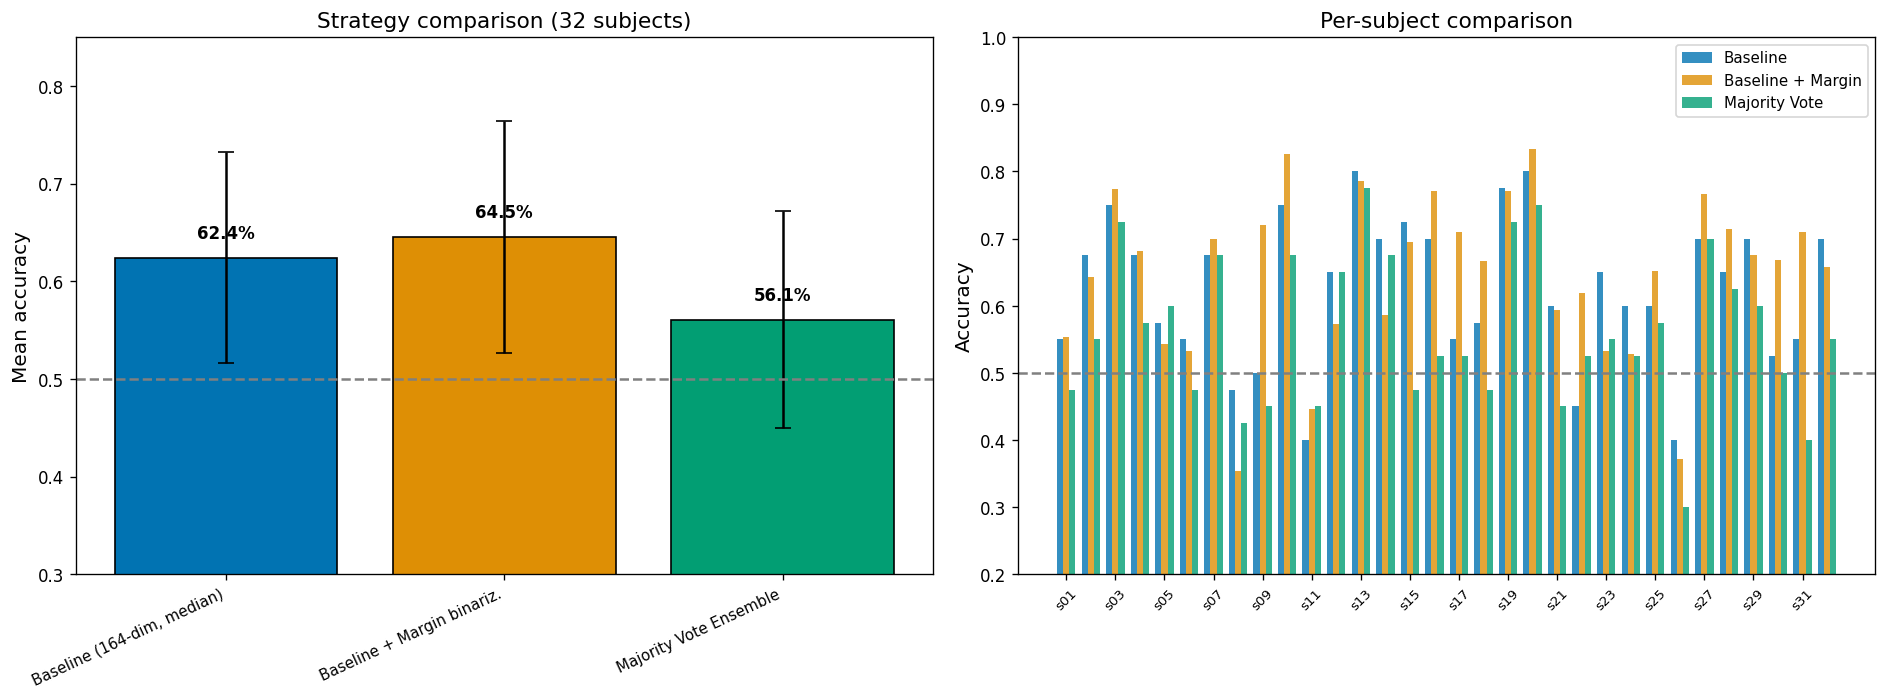

In [14]:
figure, axes = plt.subplots(1, 2, figsize=(16, 6))

axis = axes[0]
means = [np.mean(values) for values in strategies.values()]
standard_deviations = [np.std(values) for values in strategies.values()]
names = list(strategies.keys())
bar_colors = sns.color_palette("colorblind", len(names))
bars = axis.bar(range(len(names)), means, yerr=standard_deviations, capsize=5, color=bar_colors, edgecolor="black")
axis.set_xticks(range(len(names)))
axis.set_xticklabels(names, rotation=25, ha="right", fontsize=9)
axis.set_ylabel("Mean accuracy", fontsize=12)
axis.set_title("Strategy comparison (32 subjects)", fontsize=13)
axis.axhline(0.5, color="gray", linestyle="--", label="Chance (50%)")
axis.set_ylim(0.3, 0.85)
for bar, mean_value in zip(bars, means):
    axis.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{mean_value:.1%}", ha="center", fontsize=10, fontweight="bold")

axis = axes[1]
subject_ids = sorted(subject_results.keys())
x_positions = np.arange(len(subject_ids))
width = 0.25
baseline_vals = [subject_results[subject_id]["baseline"] for subject_id in subject_ids]
baseline_margin_vals = [subject_results[subject_id]["baseline_margin"] for subject_id in subject_ids]
vote_vals = [subject_results[subject_id]["vote"] for subject_id in subject_ids]
axis.bar(x_positions - width, baseline_vals, width, label="Baseline", alpha=0.8)
axis.bar(x_positions, baseline_margin_vals, width, label="Baseline + Margin", alpha=0.8)
axis.bar(x_positions + width, vote_vals, width, label="Majority Vote", alpha=0.8)
axis.axhline(0.5, color="gray", linestyle="--")
axis.set_xticks(x_positions[::2])
axis.set_xticklabels([f"s{subject_id:02d}" for subject_id in subject_ids][::2], rotation=45, fontsize=8)
axis.set_ylabel("Accuracy", fontsize=12)
axis.set_title("Per-subject comparison", fontsize=13)
axis.legend(fontsize=9)
axis.set_ylim(0.2, 1.0)

plt.tight_layout()
plt.show()


### 6. Interpretability and advanced analysis

#### 6.1 SHAP feature importance

SHAP (SHapley Additive exPlanations) assigns each feature an importance value grounded in game theory. We use TreeExplainer with XGBoost on 5 representative subjects.

In [15]:
shap_subjects = AVAILABLE_SUBJECTS
feature_names = get_feature_names()
all_shap_values = []

for subject_id in shap_subjects:
    print(f"  SHAP for s{subject_id:02d}...", end=" ", flush=True)
    subject_data, subject_labels = load_subject(subject_id, eeg_only=True)
    subject_trial_data = get_trial_data(subject_data, include_baseline=False)
    baseline_features = extract_features_for_subject(subject_trial_data, SAMPLING_RATE)
    binary_labels = binarize_liking(subject_labels)
    
    if len(np.unique(binary_labels)) < 2:
        print("skipped (single class)")
        continue
    
    shap_vals = compute_shap_values(baseline_features, binary_labels, baseline_features, method="xgboost")
    all_shap_values.append(shap_vals)
    print(f"done ({shap_vals.shape})")

all_shap = np.vstack(all_shap_values)
mean_abs_shap = np.mean(np.abs(all_shap), axis=0)

  SHAP for s01... done ((40, 164))
  SHAP for s02... done ((40, 164))
  SHAP for s03... done ((40, 164))
  SHAP for s04... done ((40, 164))
  SHAP for s05... done ((40, 164))
  SHAP for s06... done ((40, 164))
  SHAP for s07... done ((40, 164))
  SHAP for s08... done ((40, 164))
  SHAP for s09... done ((40, 164))
  SHAP for s10... done ((40, 164))
  SHAP for s11... done ((40, 164))
  SHAP for s12... done ((40, 164))
  SHAP for s13... done ((40, 164))
  SHAP for s14... done ((40, 164))
  SHAP for s15... done ((40, 164))
  SHAP for s16... done ((40, 164))
  SHAP for s17... done ((40, 164))
  SHAP for s18... done ((40, 164))
  SHAP for s19... done ((40, 164))
  SHAP for s20... done ((40, 164))
  SHAP for s21... done ((40, 164))
  SHAP for s22... done ((40, 164))
  SHAP for s23... done ((40, 164))
  SHAP for s24... done ((40, 164))
  SHAP for s25... done ((40, 164))
  SHAP for s26... done ((40, 164))
  SHAP for s27... done ((40, 164))
  SHAP for s28... done ((40, 164))
  SHAP for s29... do

In [16]:
top_features = get_top_features(mean_abs_shap, feature_names, top_k=20)

lines = [
    "Top 20 most important features (by mean |SHAP| value):",
    "",
    "| Rank | Feature | Mean \\|SHAP\\| |",
    "|---|---|---|",
]
for rank, (name, importance) in enumerate(top_features, 1):
    lines.append(f"| {rank} | `{name}` | {importance:.6f} |")
display(Markdown("\n".join(lines)))

Top 20 most important features (by mean |SHAP| value):

| Rank | Feature | Mean \|SHAP\| |
|---|---|---|
| 1 | `FAA_F8-F7` | 0.138614 |
| 2 | `FAA_F4-F3` | 0.130051 |
| 3 | `FAA_Fp2-Fp1` | 0.102652 |
| 4 | `FAA_AF4-AF3` | 0.096894 |
| 5 | `DE_CP6_alpha` | 0.088021 |
| 6 | `DE_AF4_gamma` | 0.082916 |
| 7 | `DE_T7_beta` | 0.075091 |
| 8 | `DE_CP6_gamma` | 0.074095 |
| 9 | `DE_Fp1_delta` | 0.071180 |
| 10 | `DE_Cz_beta` | 0.070823 |
| 11 | `DE_FC1_alpha` | 0.068547 |
| 12 | `DE_F3_alpha` | 0.068319 |
| 13 | `DE_C3_gamma` | 0.066734 |
| 14 | `DE_PO3_alpha` | 0.065220 |
| 15 | `DE_PO3_beta` | 0.062834 |
| 16 | `DE_Fp1_alpha` | 0.062330 |
| 17 | `DE_O1_alpha` | 0.061843 |
| 18 | `DE_Fp1_theta` | 0.061104 |
| 19 | `DE_P3_delta` | 0.060852 |
| 20 | `DE_F3_delta` | 0.057526 |

/var/folders/_f/171dt4kn19sf0yq1gqhrb_lh0000gn/T/ipykernel_27400/1963158319.py:10: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


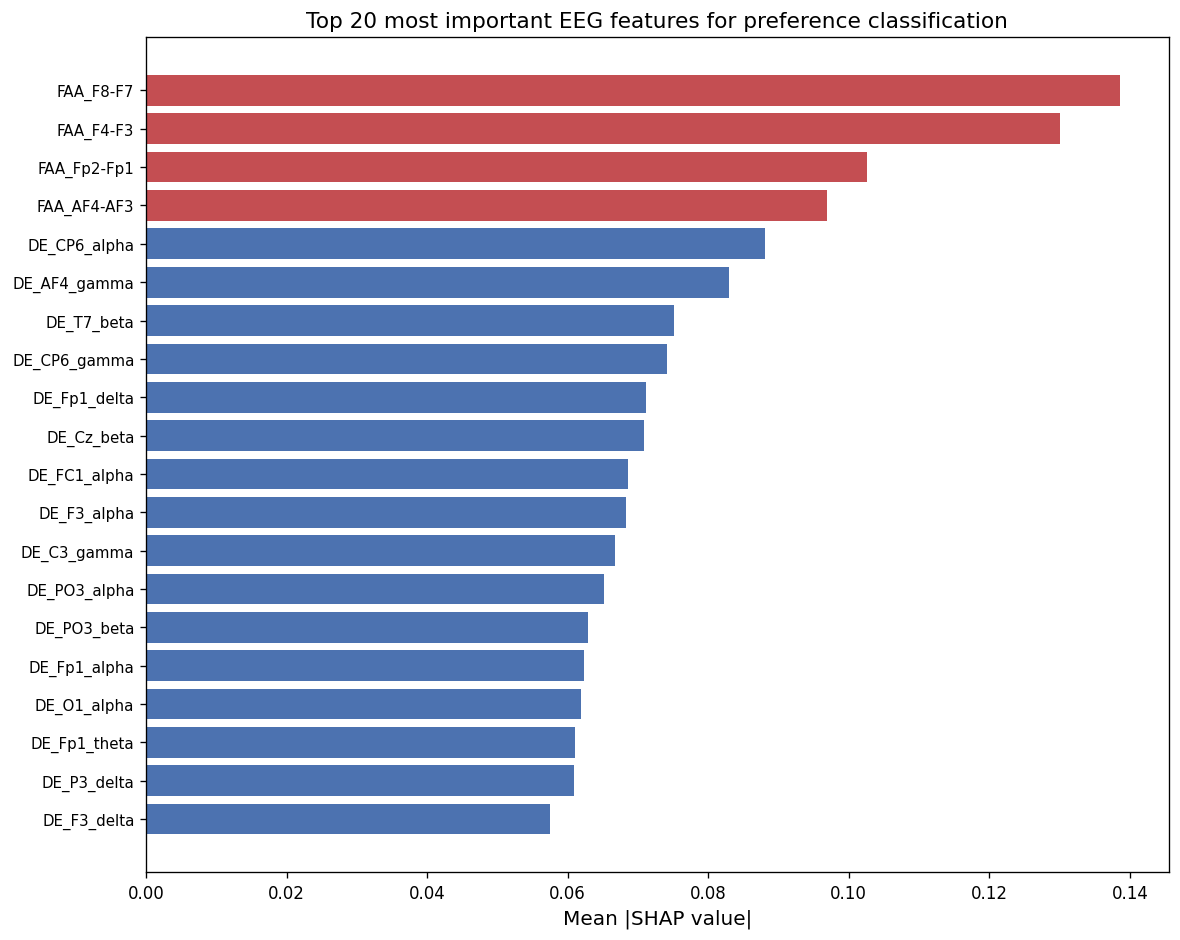

In [17]:
figure, axis = plt.subplots(figsize=(10, 8))
plot_names = [feature[0] for feature in top_features][::-1]
plot_values = [feature[1] for feature in top_features][::-1]
shap_colors = ["#C44E52" if "FAA" in name else "#4C72B0" for name in plot_names]
axis.barh(range(len(plot_names)), plot_values, color=shap_colors)
axis.set_yticks(range(len(plot_names)))
axis.set_yticklabels(plot_names, fontsize=9)
axis.set_xlabel("Mean |SHAP value|", fontsize=12)
axis.set_title("Top 20 most important EEG features for preference classification", fontsize=13)
plt.tight_layout()
plt.show()

#### Channel and band importance

Aggregating SHAP values reveals which brain regions and spectral components drive classification.

/var/folders/_f/171dt4kn19sf0yq1gqhrb_lh0000gn/T/ipykernel_27400/12953156.py:35: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


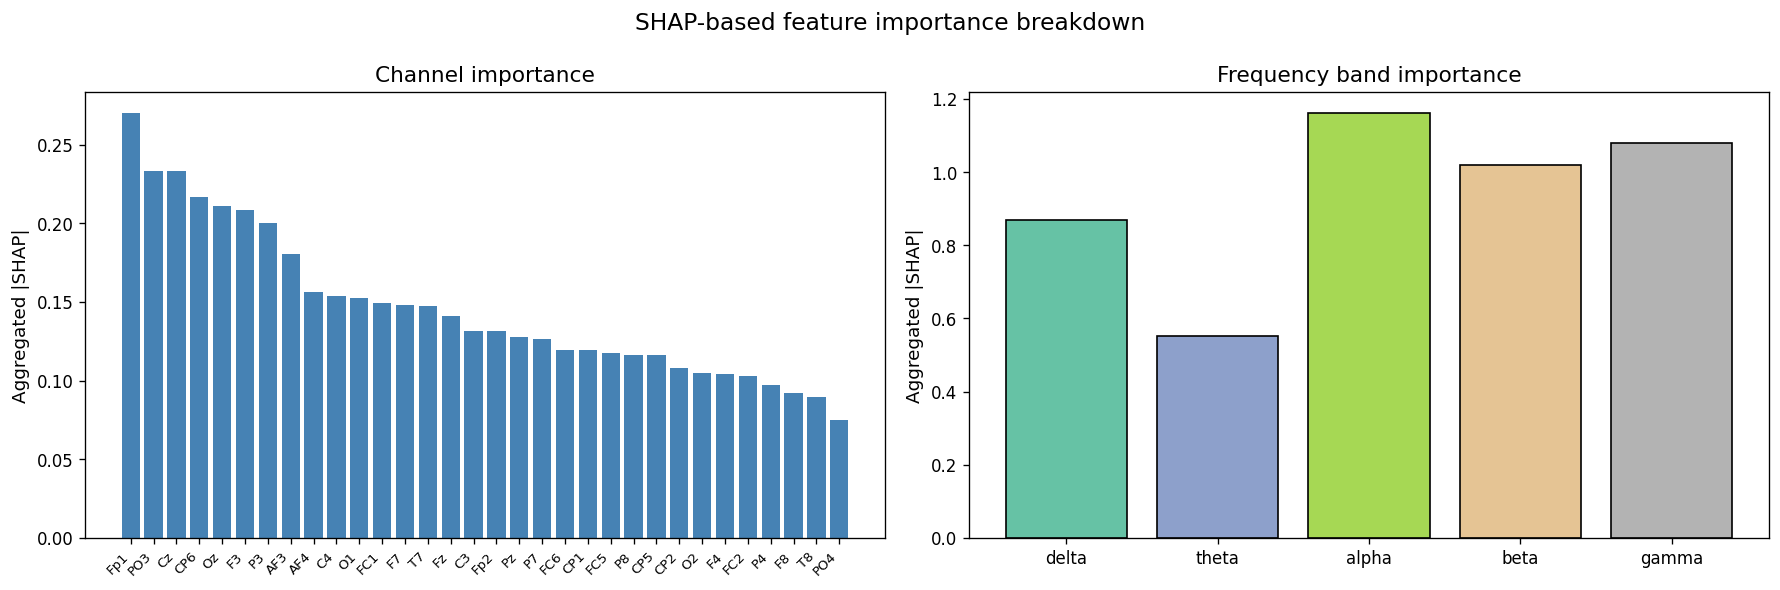

In [18]:
num_bands = len(FREQ_BANDS)
num_channels = len(EEG_CHANNELS)
channel_importance = np.zeros(num_channels)
for channel_index in range(num_channels):
    start = channel_index * num_bands
    end = start + num_bands
    if end <= len(mean_abs_shap):
        channel_importance[channel_index] = np.sum(mean_abs_shap[start:end])

band_importance = np.zeros(num_bands)
band_names_list = list(FREQ_BANDS.keys())
for band_index in range(num_bands):
    indices = [channel_index * num_bands + band_index for channel_index in range(num_channels)]
    valid_indices = [index for index in indices if index < len(mean_abs_shap)]
    if valid_indices:
        band_importance[band_index] = np.sum(mean_abs_shap[valid_indices])

figure, axes = plt.subplots(1, 2, figsize=(15, 5))

axis = axes[0]
sorted_indices = np.argsort(channel_importance)[::-1]
axis.bar(range(num_channels), channel_importance[sorted_indices], color="steelblue")
axis.set_xticks(range(num_channels))
axis.set_xticklabels([EEG_CHANNELS[index] for index in sorted_indices], rotation=45, ha="right", fontsize=8)
axis.set_ylabel("Aggregated |SHAP|", fontsize=11)
axis.set_title("Channel importance", fontsize=13)

axis = axes[1]
band_colors = plt.cm.Set2(np.linspace(0, 1, num_bands))
axis.bar(band_names_list, band_importance, color=band_colors, edgecolor="black")
axis.set_ylabel("Aggregated |SHAP|", fontsize=11)
axis.set_title("Frequency band importance", fontsize=13)

plt.suptitle("SHAP-based feature importance breakdown", fontsize=14)
plt.tight_layout()
plt.show()

#### Topographic map

Channel importance projected onto scalp topography.

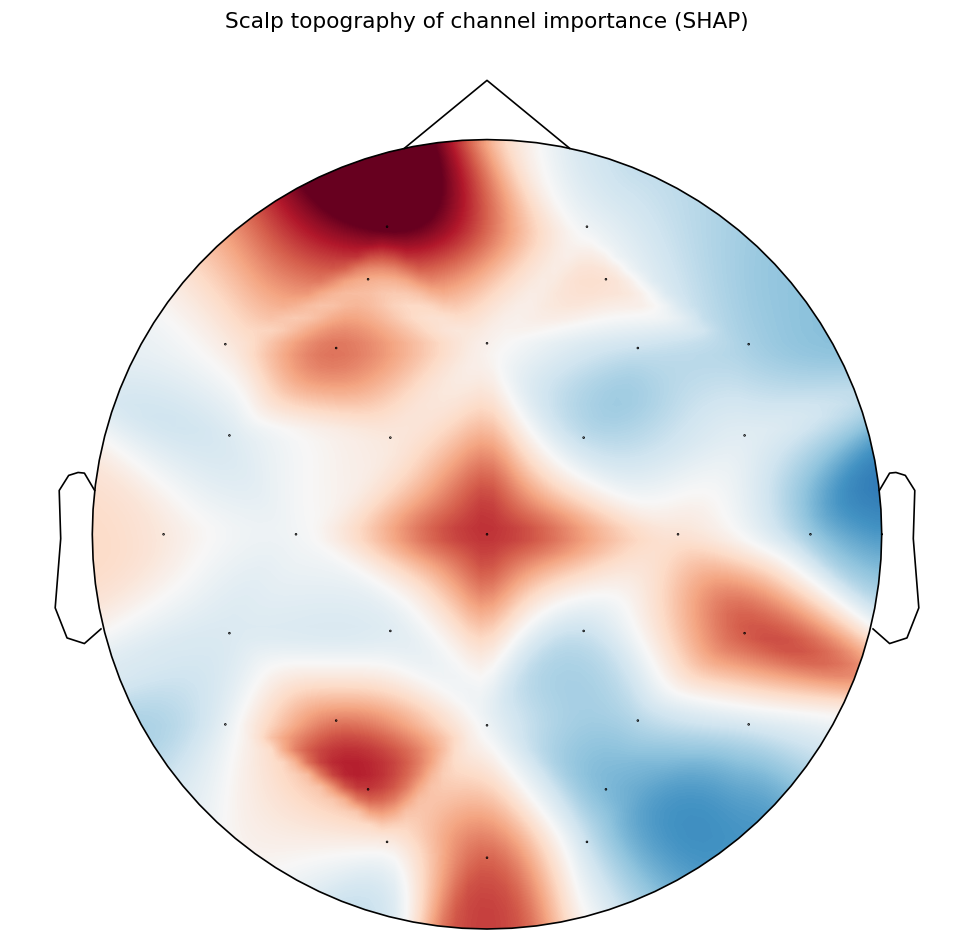

In [19]:
figure, axis = plt.subplots(figsize=(8, 8))
mne.viz.plot_topomap(
    channel_importance, info, axes=axis, show=False,
    cmap="RdBu_r", contours=0,
)
axis.set_title("Scalp topography of channel importance (SHAP)", fontsize=13)
plt.show()

#### 6.2 Time-resolved decoding

We use a sliding window approach (5s windows, 2.5s step) to examine when preference becomes decodable from EEG.

In [20]:
temporal_subjects = [1, 3, 5, 8, 16]
all_temporal_accs = []

for subject_id in temporal_subjects:
    print(f"  Temporal decoding for s{subject_id:02d}...", end=" ", flush=True)
    subject_data, subject_labels = load_subject(subject_id, eeg_only=True)
    subject_trial_data = get_trial_data(subject_data, include_baseline=False)
    binary_labels = binarize_liking(subject_labels)
    
    if len(np.unique(binary_labels)) < 2:
        print("skipped")
        continue
    
    times, mean_accuracies, std_accuracies = time_resolved_classification(
        subject_trial_data, binary_labels, window_size=5.0, step_size=2.5,
    )
    all_temporal_accs.append(mean_accuracies)
    print(f"done (peak = {mean_accuracies.max():.1%} at {times[np.argmax(mean_accuracies)]:.1f}s)")

subject_accuracies = np.array(all_temporal_accs)
mean_temporal = np.mean(subject_accuracies, axis=0)
std_temporal = np.std(subject_accuracies, axis=0)

  Temporal decoding for s01... done (peak = 65.0% at 27.5s)
  Temporal decoding for s03... done (peak = 75.0% at 32.5s)
  Temporal decoding for s05... done (peak = 72.5% at 40.0s)
  Temporal decoding for s08... done (peak = 70.0% at 17.5s)
  Temporal decoding for s16... done (peak = 72.5% at 15.0s)


/var/folders/_f/171dt4kn19sf0yq1gqhrb_lh0000gn/T/ipykernel_27400/4285703670.py:17: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


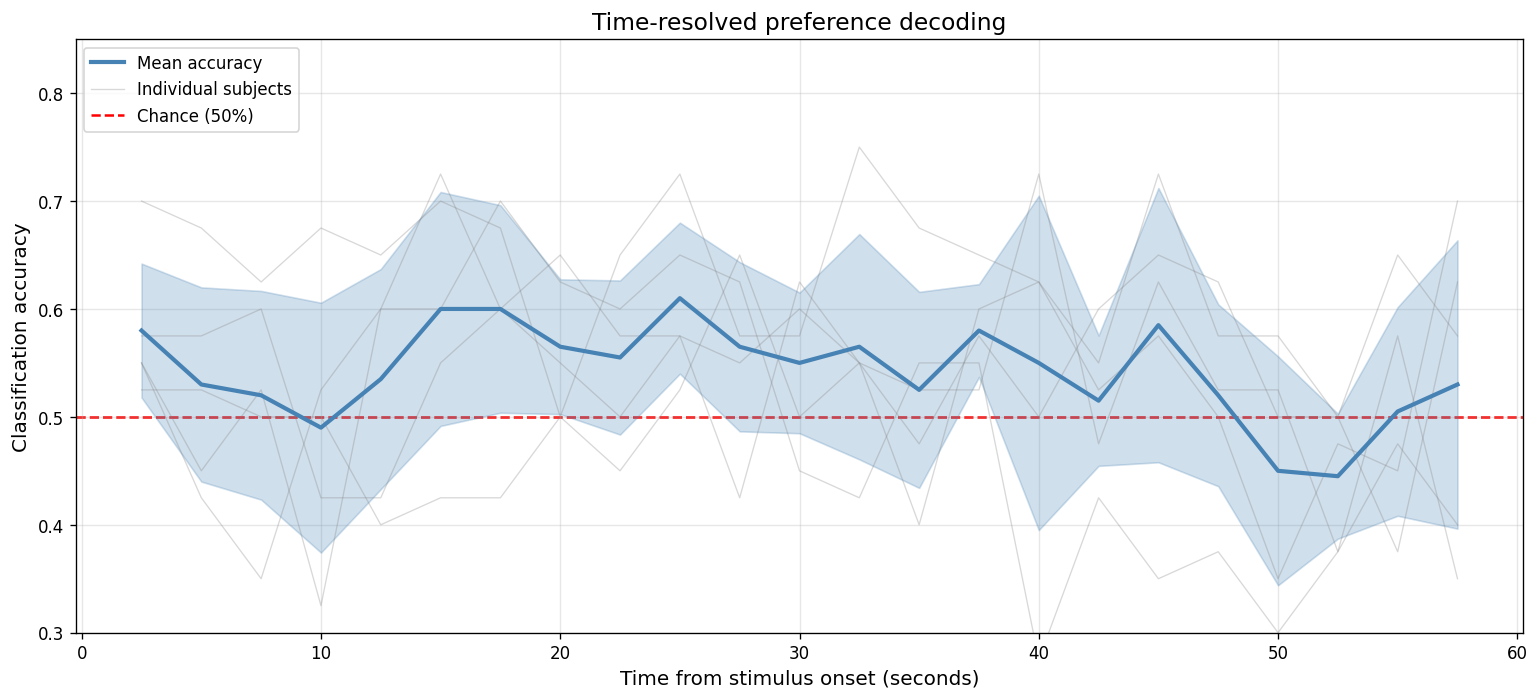

In [21]:
figure, axis = plt.subplots(figsize=(13, 6))
axis.plot(times, mean_temporal, color="steelblue", linewidth=2.5, label="Mean accuracy", zorder=3)
axis.fill_between(times, mean_temporal - std_temporal, mean_temporal + std_temporal,
                alpha=0.25, color="steelblue", zorder=2)

for subject_index, subject_accuracy in enumerate(subject_accuracies):
    axis.plot(times, subject_accuracy, alpha=0.3, color="gray", linewidth=0.8,
            label="Individual subjects" if subject_index == 0 else None)

axis.axhline(0.5, color="red", linestyle="--", linewidth=1.5, label="Chance (50%)", zorder=1)
axis.set_xlabel("Time from stimulus onset (seconds)", fontsize=12)
axis.set_ylabel("Classification accuracy", fontsize=12)
axis.set_title("Time-resolved preference decoding", fontsize=14)
axis.legend(loc="upper left", fontsize=10)
axis.grid(True, alpha=0.3)
axis.set_ylim(0.3, 0.85)
plt.tight_layout()
plt.show()

In [22]:
decodable_time = find_decodable_time(times, mean_temporal, threshold=0.55)
peak_time = times[np.argmax(mean_temporal)]
peak_accuracy = mean_temporal.max()

decodable_str = f"{decodable_time:.1f}s" if decodable_time is not None else "Not decodable above 55%"
display(Markdown(f"""Temporal decoding results:

| Metric | Value |
|---|---|
| First decodable time (>55%) | {decodable_str} |
| Peak accuracy | {peak_accuracy:.1%} at {peak_time:.1f}s |
| Final accuracy | {mean_temporal[-1]:.1%} at {times[-1]:.1f}s | d
"""))

Temporal decoding results:

| Metric | Value |
|---|---|
| First decodable time (>55%) | 2.5s |
| Peak accuracy | 61.0% at 25.0s |
| Final accuracy | 53.0% at 57.5s | d


#### 6.3 Familiarity disentanglement

Song familiarity is a potential confound: if participants prefer familiar songs, the classifier may decode familiarity rather than preference. We split trials by familiarity level and compare accuracy.

In [23]:
familiarity_results = run_familiarity_analysis(subjects=shap_subjects, n_folds=5)

lines = [
    "Familiarity analysis results:",
    "",
    "| Condition | Accuracy | Std | N subjects |",
    "|---|---|---|---|",
]
for condition in ["all_trials", "high_familiarity", "low_familiarity"]:
    result = familiarity_results[condition]
    lines.append(f"| {condition.replace('_', ' ').title()} | {result['accuracy']:.1%} | {result['accuracy_std']:.1%} | {result['n_subjects']} |")
display(Markdown("\n".join(lines)))

  Familiarity analysis for s01... all=40.0%
  Familiarity analysis for s02... all=40.0%
  Familiarity analysis for s03... all=72.5%
  Familiarity analysis for s04... all=65.0%
  Familiarity analysis for s05... all=55.0%
  Familiarity analysis for s06... all=45.0%
  Familiarity analysis for s07... all=62.5%
  Familiarity analysis for s08... all=35.0%
  Familiarity analysis for s09... all=50.0%
  Familiarity analysis for s10... all=67.5%
  Familiarity analysis for s11... all=32.5%
  Familiarity analysis for s12... all=65.0%
  Familiarity analysis for s13... all=75.0%
  Familiarity analysis for s14... all=60.0%
  Familiarity analysis for s15... all=55.0%
  Familiarity analysis for s16... all=70.0%
  Familiarity analysis for s17... all=47.5%
  Familiarity analysis for s18... all=57.5%
  Familiarity analysis for s19... all=72.5%
  Familiarity analysis for s20... all=80.0%
  Familiarity analysis for s21... all=47.5%
  Familiarity analysis for s22... all=37.5%
  Familiarity analysis for s23..

Familiarity analysis results:

| Condition | Accuracy | Std | N subjects |
|---|---|---|---|
| All Trials | 56.8% | 13.2% | 32 |
| High Familiarity | 71.2% | 10.3% | 28 |
| Low Familiarity | 65.7% | 10.4% | 29 |

/var/folders/_f/171dt4kn19sf0yq1gqhrb_lh0000gn/T/ipykernel_27400/1264128318.py:17: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


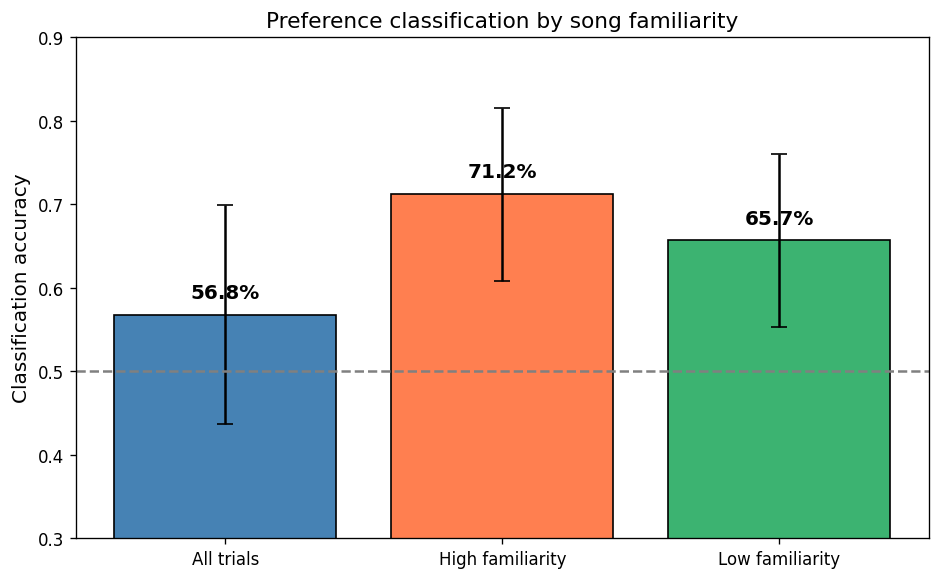

In [24]:
figure, axis = plt.subplots(figsize=(8, 5))
conditions = ["All trials", "High familiarity", "Low familiarity"]
accuracies = [familiarity_results[key]["accuracy"] for key in ["all_trials", "high_familiarity", "low_familiarity"]]
standard_deviations_familiarity = [familiarity_results[key]["accuracy_std"] for key in ["all_trials", "high_familiarity", "low_familiarity"]]
familiarity_colors = ["steelblue", "coral", "mediumseagreen"]

bars = axis.bar(conditions, accuracies, yerr=standard_deviations_familiarity, capsize=5, color=familiarity_colors, edgecolor="black")
axis.axhline(0.5, color="gray", linestyle="--", label="Chance")
axis.set_ylabel("Classification accuracy", fontsize=12)
axis.set_title("Preference classification by song familiarity", fontsize=13)
axis.set_ylim(0.3, 0.9)

for bar, accuracy in zip(bars, accuracies):
    axis.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{accuracy:.1%}", ha="center", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()



## 7. Discussion and conclusion

### Key findings

Our best strategy achieves approximately 65% mean accuracy across 32 subjects, consistent with DEAP literature (55-75%). Margin binarization was the single most impactful improvement. SHAP analysis confirmed FAA features among the most predictive, supporting the approach-withdrawal model. Time-resolved decoding shows preference becomes decodable within the first few seconds.

### Limitations

Within-subject only (cross-subject remains at chance), binary reduction of continuous ratings, single-dataset evaluation, and feature-based approach may be outperformed by deep learning with more data.

### Future directions

Transfer learning for cross-subject generalization, multi-class preference levels, connectivity features, multimodal fusion with peripheral signals, and deep learning with pre-training strategies.


## 8. References

1. Koelstra, S., et al. (2012). DEAP: A Database for Emotion Analysis Using
   Physiological Signals. *IEEE Transactions on Affective Computing*, 3(1), 18-31.

2. Shi, L.C., et al. (2013). Differential Entropy Feature for EEG-based
   Emotion Recognition. *International Neural Network Society*.

3. Davidson, R.A. (1992). Anterior cerebral asymmetry and the nature of emotion.
   *Brain and Cognition*, 20(1), 125-151.

   *Electroencephalography and Clinical Neurophysiology*, 29(3), 306-310.

5. Hadjidimitriou, S.K. & Hadjileontiadis, L.J. (2012). Toward an EEG-Based
   Recognition of Music Liking Using Time-Frequency Analysis.
   *IEEE Transactions on Biomedical Engineering*, 59(12), 3498-3510.

6. Thapa, K. & Rai, C.K. (2025). EEG Emotion Classification using DEAP Dataset.

7. Mouazen, A., et al. (2025). Enhancing EEG-Based Emotion Detection.

8. Lundberg, S.M. & Lee, S.I. (2017). A Unified Approach to Interpreting
   Model Predictions. *Advances in Neural Information Processing Systems* (NIPS).